In [37]:
!pip install pytrends pandas matplotlib seaborn scipy

In [38]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, f_oneway

In [39]:
pytrends = TrendReq(hl='en-US', tz=360)

keywords = ["matcha", "matcha latte"]
pytrends.build_payload(keywords, timeframe='today 12-m', geo='')

trends_data = pytrends.interest_over_time()
trends_data = trends_data.reset_index()

trends_data.head()

/opt/anaconda3/lib/python3.13/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,date,matcha,matcha latte,isPartial
0,2025-04-13,71,7,False
1,2025-04-20,73,7,False
2,2025-04-27,84,7,False
3,2025-05-04,77,8,False
4,2025-05-11,73,7,False


In [40]:
trends_data.to_csv("google_trends_matcha.csv", index=False)
print("Google Trends verisi kaydedildi.")

Google Trends verisi kaydedildi.


In [41]:
print("Veri boyutu:", trends_data.shape)
trends_data.head(10)

Veri boyutu: (53, 4)


,date,matcha,matcha latte,isPartial
0,2025-04-13,71,7,False
1,2025-04-20,73,7,False
2,2025-04-27,84,7,False
3,2025-05-04,77,8,False
4,2025-05-11,73,7,False
5,2025-05-18,77,7,False
6,2025-05-25,78,7,False
7,2025-06-01,81,7,False
8,2025-06-08,79,7,False
9,2025-06-15,75,6,False


In [42]:
trends_data["date"] = pd.to_datetime(trends_data["date"])
trends_data.dtypes

date            datetime64[ns]
matcha                   int64
matcha latte             int64
isPartial                 bool
dtype: object

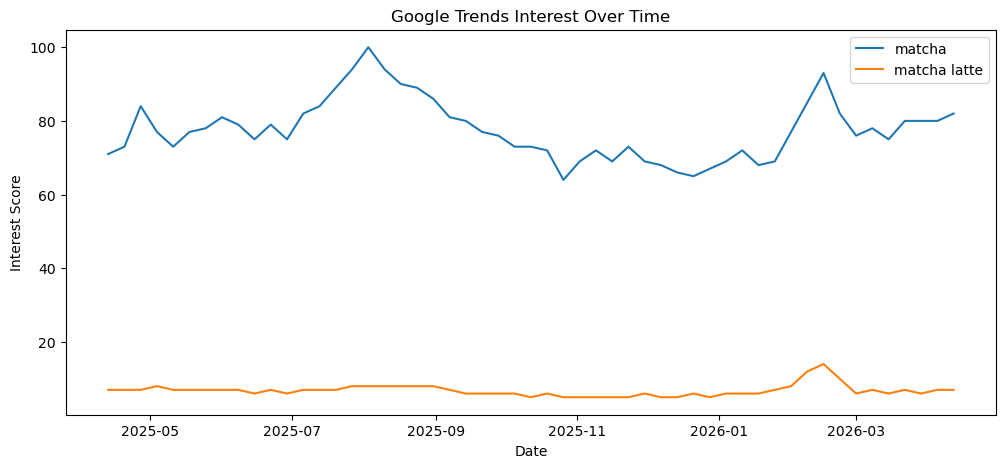

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(trends_data["date"], trends_data["matcha"], label="matcha")
plt.plot(trends_data["date"], trends_data["matcha latte"], label="matcha latte")

plt.title("Google Trends Interest Over Time")
plt.xlabel("Date")
plt.ylabel("Interest Score")
plt.legend()
plt.show()

In [44]:
pytrends = TrendReq(hl='en-US', tz=360)

keywords = ["matcha", "matcha latte"]
pytrends.build_payload(keywords, timeframe='today 5-y', geo='')

trends_data_5y = pytrends.interest_over_time()
trends_data_5y = trends_data_5y.reset_index()

trends_data_5y.head()

/opt/anaconda3/lib/python3.13/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,date,matcha,matcha latte,isPartial
0,2021-04-11,21,2,False
1,2021-04-18,20,2,False
2,2021-04-25,21,2,False
3,2021-05-02,21,2,False
4,2021-05-09,19,2,False


In [45]:
trends_data_5y.to_csv("google_trends_matcha_5y.csv", index=False)
print("5 yıllık Google Trends verisi kaydedildi.")

5 yıllık Google Trends verisi kaydedildi.


In [46]:
trends_data_5y["date"] = pd.to_datetime(trends_data_5y["date"])
trends_data_5y.dtypes

date            datetime64[ns]
matcha                   int64
matcha latte             int64
isPartial                 bool
dtype: object

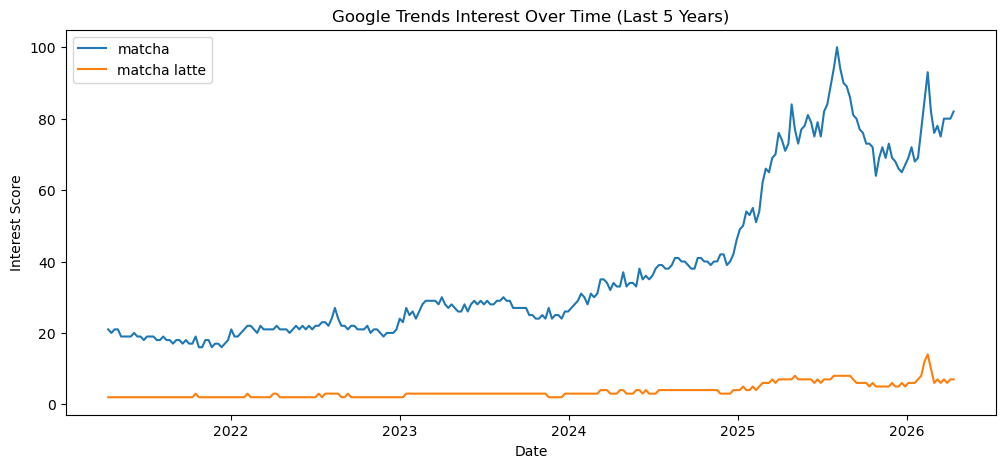

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(trends_data_5y["date"], trends_data_5y["matcha"], label="matcha")
plt.plot(trends_data_5y["date"], trends_data_5y["matcha latte"], label="matcha latte")

plt.title("Google Trends Interest Over Time (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Interest Score")
plt.legend()
plt.show()

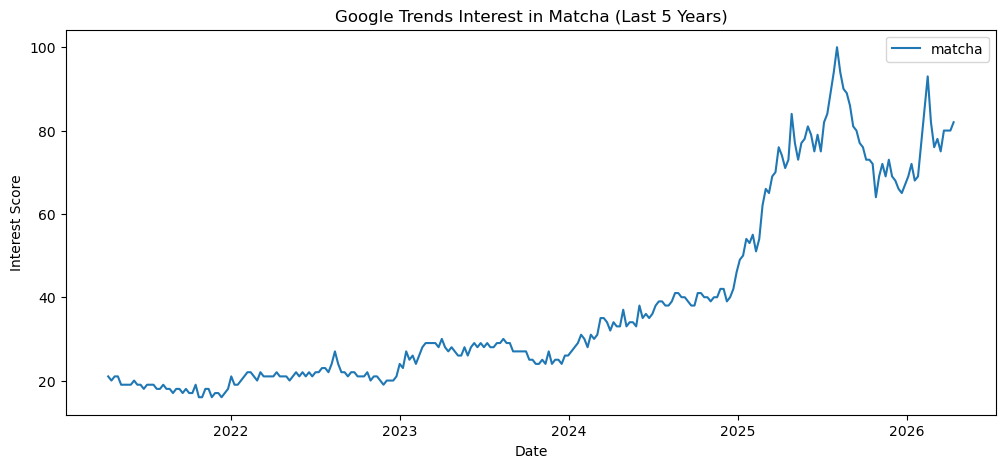

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(trends_data_5y["date"], trends_data_5y["matcha"], label="matcha")

plt.title("Google Trends Interest in Matcha (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Interest Score")
plt.legend()
plt.show()

In [49]:
real_data = [
    ["Carrington Farms Organic Matcha Green Tea Powder, 3.5oz", 8.74, 4.3, 473, "powder", "Walmart", "2026-04-13"],
    ["Morning Made Ceremonial Grade Organic Matcha Latte Powder, Vanilla, 10 pack (0.18oz ea)", 8.98, 4.3, 227, "latte_mix", "Walmart", "2026-04-13"],
    ["Jade Leaf Organic Ceremonial Grade Matcha Powder, Barista Edition, 1.06 oz Tin", 19.99, 4.6, 907, "ceremonial", "Walmart", "2026-04-13"],
    ["Jade Leaf Matcha, Organic Japanese Culinary Matcha, Powdered Tea, 0.7 Oz", 8.64, 4.5, 1699, "powder", "Walmart", "2026-04-13"],
    ["Jade Leaf Matcha, Organic Japanese Matcha Latte Mix, Powdered Tea, 3.5 Oz", 8.64, 4.4, 1847, "latte_mix", "Walmart", "2026-04-13"],
    ["Jade Leaf Organic Matcha Latte Mix, Original, Dairy-Free Matcha Green Tea Powder, 17.6 oz Tub", 24.79, 4.6, 611, "latte_mix", "Walmart", "2026-04-13"],
    ["Terrasoul Superfoods Organic Matcha Green Tea (Ceremonial Grade in Miron Glass), 4.24 Oz / 120g (2.12 Oz 2-Pack)", 37.99, 4.9, 78, "ceremonial", "Walmart", "2026-04-13"],
    ["MatchAiA USDA-Certified Organic Matcha, 100% Pure Green Tea Powder, Premium Culinary Grade for Lattes, Smoothies, Desserts and Baking, Sugar Free, Gluten Free (60g / 2.1oz Pouch)", 8.95, 4.6, 19, "powder", "Walmart", "2026-04-13"],
    ["Everyday Matcha 100% Japanese Green Tea Powder, 12 Ounce", 33.00, 4.8, 12, "powder", "Walmart", "2026-04-13"],
    ["uVernal Organic Matcha Green Tea Powder - 100% Pure Matcha for Smoothies Latte and Baking Easy to Mix - 4oz", 14.99, 4.8, 1029, "powder", "Walmart", "2026-04-13"],
    ["Jade Leaf Organic Matcha Latte Mix, Original, Dairy-Free Matcha Green Tea Powder, 17.6 oz Tub", 30.99, 4.6, 628, "latte_mix", "Walmart", "2026-04-13"],
    ["Melting Forest Mushroom Matcha Powder with Reishi, Lion’s Mane, Organic Adaptogen Blend, GMO-Free, 30 Count", 14.99, 5.0, 1, "powder", "Walmart", "2026-04-13"]
]

products = pd.DataFrame(real_data,  columns=[
    "product_name",
    "price",
    "rating",
    "review_count",
    "category",
    "source",
    "date_collected"
])

products

,product_name,price,rating,review_count,category,source,date_collected
0,Carrington Farms Organic Matcha Green Tea Powd...,8.74,4.3,473,powder,Walmart,2026-04-13
1,Morning Made Ceremonial Grade Organic Matcha L...,8.98,4.3,227,latte_mix,Walmart,2026-04-13
2,Jade Leaf Organic Ceremonial Grade Matcha Powd...,19.99,4.6,907,ceremonial,Walmart,2026-04-13
3,"Jade Leaf Matcha, Organic Japanese Culinary Ma...",8.64,4.5,1699,powder,Walmart,2026-04-13
4,"Jade Leaf Matcha, Organic Japanese Matcha Latt...",8.64,4.4,1847,latte_mix,Walmart,2026-04-13
5,"Jade Leaf Organic Matcha Latte Mix, Original, ...",24.79,4.6,611,latte_mix,Walmart,2026-04-13
6,Terrasoul Superfoods Organic Matcha Green Tea ...,37.99,4.9,78,ceremonial,Walmart,2026-04-13
7,"MatchAiA USDA-Certified Organic Matcha, 100% P...",8.95,4.6,19,powder,Walmart,2026-04-13
8,Everyday Matcha 100% Japanese Green Tea Powder...,33.00,4.8,12,powder,Walmart,2026-04-13
9,uVernal Organic Matcha Green Tea Powder - 100%...,14.99,4.8,1029,powder,Walmart,2026-04-13


In [50]:
products.to_csv("matcha_products_real.csv", index=False)
print("Gerçek ürün verisi kaydedildi.")

Gerçek ürün verisi kaydedildi.


In [51]:
print("Boyut:", products.shape)
print(products.dtypes)
products.head()

Boyut: (12, 7)
product_name       object
price             float64
rating            float64
review_count        int64
category           object
source             object
date_collected     object
dtype: object


,product_name,price,rating,review_count,category,source,date_collected
0,Carrington Farms Organic Matcha Green Tea Powd...,8.74,4.3,473,powder,Walmart,2026-04-13
1,Morning Made Ceremonial Grade Organic Matcha L...,8.98,4.3,227,latte_mix,Walmart,2026-04-13
2,Jade Leaf Organic Ceremonial Grade Matcha Powd...,19.99,4.6,907,ceremonial,Walmart,2026-04-13
3,"Jade Leaf Matcha, Organic Japanese Culinary Ma...",8.64,4.5,1699,powder,Walmart,2026-04-13
4,"Jade Leaf Matcha, Organic Japanese Matcha Latt...",8.64,4.4,1847,latte_mix,Walmart,2026-04-13


In [52]:
products["price"] = pd.to_numeric(products["price"], errors="coerce")
products["rating"] = pd.to_numeric(products["rating"], errors="coerce")
products["review_count"] = pd.to_numeric(products["review_count"], errors="coerce")
products["date_collected"] = pd.to_datetime(products["date_collected"])

products = products.drop_duplicates()
products = products.dropna()

print("Temizlenmiş boyut:", products.shape)
products

Temizlenmiş boyut: (12, 7)


,product_name,price,rating,review_count,category,source,date_collected
0,Carrington Farms Organic Matcha Green Tea Powd...,8.74,4.3,473,powder,Walmart,2026-04-13
1,Morning Made Ceremonial Grade Organic Matcha L...,8.98,4.3,227,latte_mix,Walmart,2026-04-13
2,Jade Leaf Organic Ceremonial Grade Matcha Powd...,19.99,4.6,907,ceremonial,Walmart,2026-04-13
3,"Jade Leaf Matcha, Organic Japanese Culinary Ma...",8.64,4.5,1699,powder,Walmart,2026-04-13
4,"Jade Leaf Matcha, Organic Japanese Matcha Latt...",8.64,4.4,1847,latte_mix,Walmart,2026-04-13
5,"Jade Leaf Organic Matcha Latte Mix, Original, ...",24.79,4.6,611,latte_mix,Walmart,2026-04-13
6,Terrasoul Superfoods Organic Matcha Green Tea ...,37.99,4.9,78,ceremonial,Walmart,2026-04-13
7,"MatchAiA USDA-Certified Organic Matcha, 100% P...",8.95,4.6,19,powder,Walmart,2026-04-13
8,Everyday Matcha 100% Japanese Green Tea Powder...,33.00,4.8,12,powder,Walmart,2026-04-13
9,uVernal Organic Matcha Green Tea Powder - 100%...,14.99,4.8,1029,powder,Walmart,2026-04-13


In [53]:
products.describe()

,price,rating,review_count,date_collected
count,12.000000,12.000000,12.000000,12
mean,18.390833,4.616667,627.583333,2026-04-13 00:00:00
min,8.640000,4.300000,1.000000,2026-04-13 00:00:00
25%,8.897500,4.475000,63.250000,2026-04-13 00:00:00
50%,14.990000,4.600000,542.000000,2026-04-13 00:00:00
75%,26.340000,4.800000,937.500000,2026-04-13 00:00:00
max,37.990000,5.000000,1847.000000,2026-04-13 00:00:00
std,10.803709,0.224958,639.795629,NaN


In [54]:
products["category"].value_counts()

category
powder        6
latte_mix     4
ceremonial    2
Name: count, dtype: int64

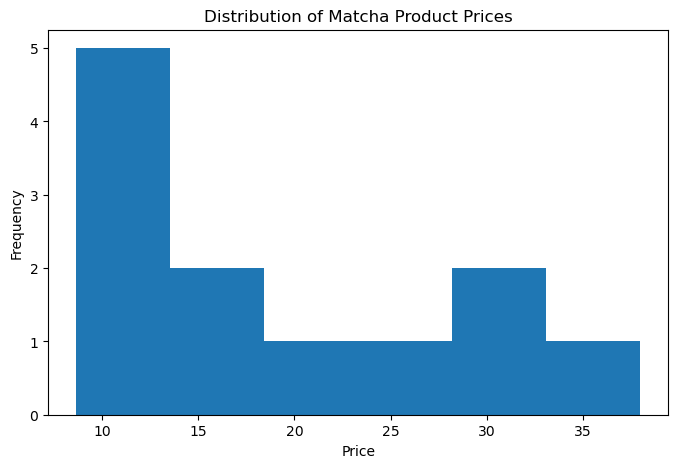

In [55]:
plt.figure(figsize=(8, 5))
plt.hist(products["price"], bins=6)
plt.title("Distribution of Matcha Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

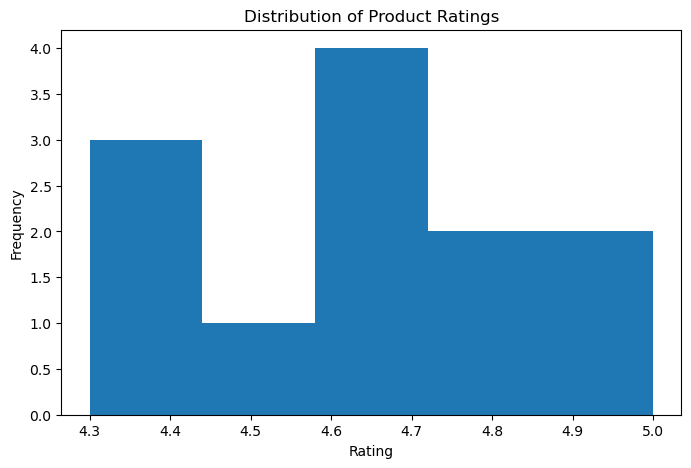

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(products["rating"], bins=5)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

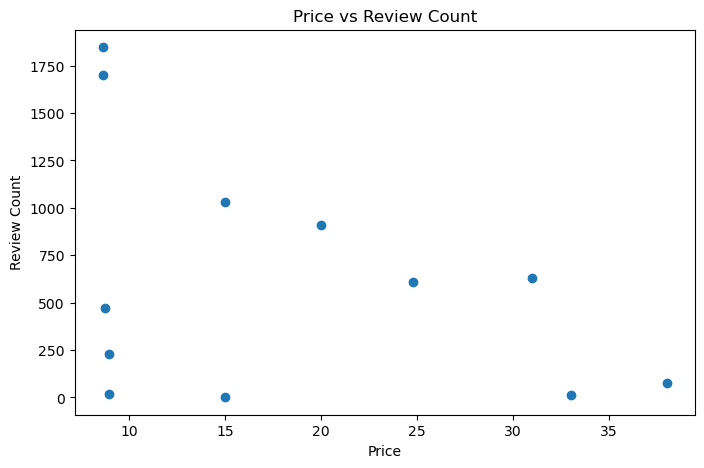

In [57]:
plt.figure(figsize=(8, 5))
plt.scatter(products["price"], products["review_count"])
plt.title("Price vs Review Count")
plt.xlabel("Price")
plt.ylabel("Review Count")
plt.show()

In [58]:
corr, p_value = spearmanr(products["price"], products["review_count"])

print("Spearman correlation:", corr)
print("p-value:", p_value)

Spearman correlation: -0.42807281055172736
p-value: 0.16505280636941294


In [59]:
category_summary = products.groupby("category")[["price", "rating", "review_count"]].mean()
category_summary

,price,rating,review_count
category,,,
ceremonial,28.990,4.750000,492.500000
latte_mix,18.350,4.475000,828.250000
powder,14.885,4.666667,538.833333


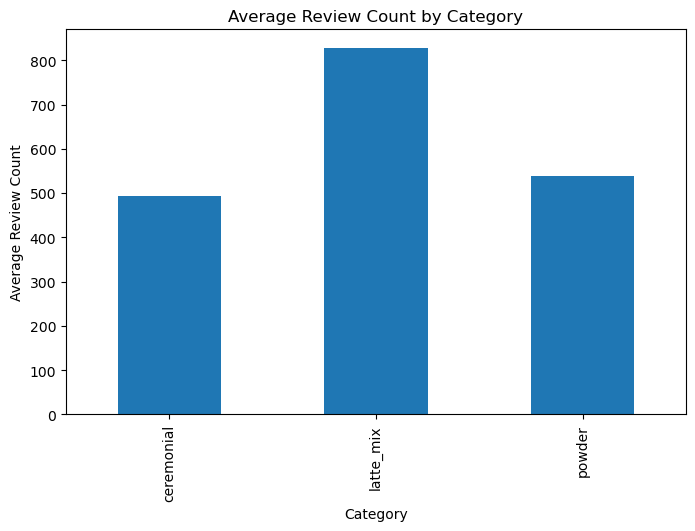

In [60]:
category_summary["review_count"].plot(kind="bar", figsize=(8,5))
plt.title("Average Review Count by Category")
plt.xlabel("Category")
plt.ylabel("Average Review Count")
plt.show()

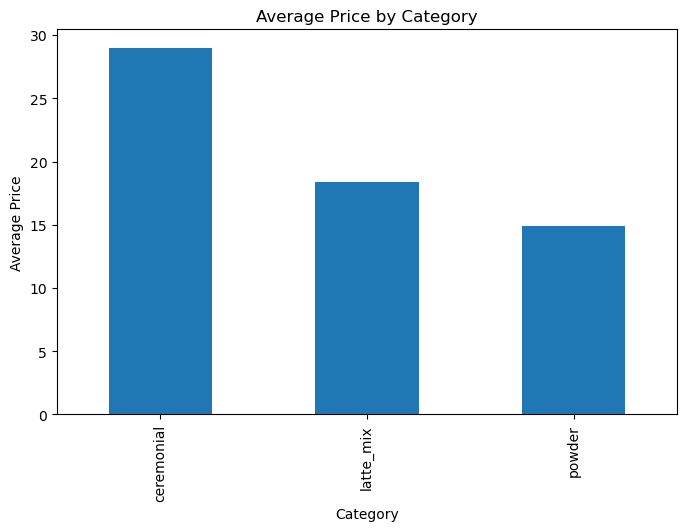

In [61]:
category_summary["price"].plot(kind="bar", figsize=(8,5))
plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.show()

In [62]:
from scipy.stats import kruskal

In [63]:
groups = [group["review_count"].values for name, group in products.groupby("category")]

stat, p_value_kw = kruskal(*groups)

print("Kruskal-Wallis statistic:", stat)
print("p-value:", p_value_kw)

Kruskal-Wallis statistic: 1.1538461538461533
p-value: 0.5616237838971457


In [64]:
products.to_csv("matcha_products_clean.csv", index=False)
print("Temiz ürün verisi kaydedildi.")

Temiz ürün verisi kaydedildi.


### Google Trends Analysis
The 5-year Google Trends data suggests that online interest in matcha has increased over time, especially from 2024 onward.

### Product Data Collection
Product-level data was collected from publicly available retail pages. The dataset includes product name, price, rating, review count, category, source, and collection date.

### Exploratory Data Analysis
The dataset shows variation in price, rating, and review count across product categories. The current sample includes powder, latte mix, and ceremonial products.

### Hypothesis Test 1: Price vs Review Count
A Spearman correlation test was used to examine the relationship between price and review count. The correlation coefficient is negative, suggesting a possible inverse relationship, but the p-value is greater than 0.05. Therefore, the result is not statistically significant.

### Hypothesis Test 2: Category Differences in Review Count
A Kruskal-Wallis test was used to examine whether review counts differ across product categories. The p-value is greater than 0.05, so the current sample does not provide strong evidence of a statistically significant difference between categories.

### Limitation
The current product dataset is relatively small and represents a snapshot collected on a single date. Therefore, the results should be interpreted cautiously.